# Descriptive Analysis
Loads the final processed dataset and produces baseline descriptive stats and plots.

In [1]:
# ============================================
# Notebook 4: Descriptive Analysis
# ============================================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

# --------------------------------------------
# 1. Load final dataset
# --------------------------------------------
INPUT_FILE = os.getenv("INPUT_FILE", "Processed_Reviews.csv")
df = pd.read_csv(INPUT_FILE)
print(f"Loaded: {INPUT_FILE}")
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Loaded: Processed_Reviews.csv
Shape: (16156, 41)

Columns:
['Location_Name', 'Located_City', 'Province', 'District', 'Location_Type', 'User_Locale', 'User_Country', 'User_Region', 'Travel_Date_Month', 'Travel_Date_Year', 'Published_Date_Month', 'Published_Date_Year', 'User_Contributions', 'Rating', 'Helpful_Votes', 'Review_Length', 'Title_Length', 'Rating_Class', 'Review_Delay_Days', 'Combined_Text', 'Combined_Sentiment', 'Sentiment_Score', 'Emotion', 'Dominant_Topic', 'Topic_Probability', 'Topic_Keywords', 'Review_Theme', 'Sentiment_Rating_Gap', 'Length_Bucket', 'Has_Helpful_Votes', 'Helpfulness_Ratio', 'Helpful_Bucket', 'Reviewer_Experience', 'Sentiment_Numeric', 'Location_Avg_Rating', 'Location_Review_Count', 'Location_Sentiment_Mean', 'Rank_By_Rating', 'Rank_By_Popularity', 'Popularity_Quality_Gap', 'Review_Quality_Score']


In [2]:
# --------------------------------------------
# 2. Basic overview
# --------------------------------------------
print("\n=== Dataset Overview ===")
print(f"Number of rows: {len(df):,}")
print(f"Number of columns: {df.shape[1]}")

print("\n=== Data Types ===")
print(df.dtypes)

print("\n=== Missing Values ===")
print(df.isnull().sum().sort_values(ascending=False))

print("\n=== Duplicate Rows ===")
print(df.duplicated().sum())


=== Dataset Overview ===
Number of rows: 16,156
Number of columns: 41

=== Data Types ===
Location_Name                  str
Located_City                   str
Province                       str
District                       str
Location_Type                  str
User_Locale                    str
User_Country                   str
User_Region                    str
Travel_Date_Month            int64
Travel_Date_Year             int64
Published_Date_Month         int64
Published_Date_Year          int64
User_Contributions           int64
Rating                       int64
Helpful_Votes                int64
Review_Length                int64
Title_Length                 int64
Rating_Class                   str
Review_Delay_Days            int64
Combined_Text                  str
Combined_Sentiment             str
Sentiment_Score            float64
Emotion                        str
Dominant_Topic               int64
Topic_Probability          float64
Topic_Keywords                 str

In [3]:
# --------------------------------------------
# 3. Basic distributions
# --------------------------------------------
print("\n=== Rating Distribution ===")
print(df["Rating"].value_counts().sort_index())

print("\n=== Rating Percentage Distribution ===")
print((df["Rating"].value_counts(normalize=True) * 100).round(2))

print("\n=== Rating Class Distribution ===")
if "Rating_Class" in df.columns:
    print(df["Rating_Class"].value_counts())

print("\n=== Sentiment Distribution ===")
if "Combined_Sentiment" in df.columns:
    print(df["Combined_Sentiment"].value_counts())

print("\n=== Location Type Distribution ===")
print(df["Location_Type"].value_counts().head(15))

print("\n=== Top 10 Cities by Review Count ===")
print(df["Located_City"].value_counts().head(10))

print("\n=== Top 10 Destinations by Review Count ===")
print(df["Location_Name"].value_counts().head(10))

print("\n=== Top 10 Countries by Review Count ===")
if "User_Country" in df.columns:
    print(df["User_Country"].value_counts().head(10))


=== Rating Distribution ===
Rating
1     487
2     658
3    2166
4    5196
5    7649
Name: count, dtype: int64

=== Rating Percentage Distribution ===
Rating
5    47.34
4    32.16
3    13.41
2     4.07
1     3.01
Name: proportion, dtype: float64

=== Rating Class Distribution ===
Rating_Class
Positive    12845
Neutral      2166
Negative     1145
Name: count, dtype: int64

=== Sentiment Distribution ===
Combined_Sentiment
POSITIVE    12764
NEUTRAL      1818
NEGATIVE     1574
Name: count, dtype: int64

=== Location Type Distribution ===
Location_Type
Religious Sites            3017
Beaches                    2110
Farms                      1884
Nature & Wildlife Areas    1557
Museums                    1525
Historic Sites             1519
Gardens                    1354
National Parks             1205
Waterfalls                  933
Bodies of Water             839
Zoological Gardens          213
Name: count, dtype: int64

=== Top 10 Cities by Review Count ===
Located_City
Nuwara Eliya  

In [4]:
# --------------------------------------------
# 4. Summary statistics
# --------------------------------------------
numeric_cols = [
    col for col in [
        "Rating",
        "Helpful_Votes",
        "User_Contributions",
        "Review_Length",
        "Title_Length",
        "Review_Delay_Days",
    ]
    if col in df.columns
]

print("\n=== Numeric Summary ===")
print(df[numeric_cols].describe())

# --------------------------------------------
# 5. Helpful review overview
# --------------------------------------------
if "Has_Helpful_Votes" in df.columns:
    print("\n=== Helpful Vote Flag Distribution ===")
    print(df["Has_Helpful_Votes"].value_counts())

if "Helpful_Bucket" in df.columns:
    print("\n=== Helpful Bucket Distribution ===")
    print(df["Helpful_Bucket"].value_counts())

if "Reviewer_Experience" in df.columns:
    print("\n=== Reviewer Experience Distribution ===")
    print(df["Reviewer_Experience"].value_counts())

print("\n=== Avg Helpful Votes by Rating ===")
print(df.groupby("Rating")["Helpful_Votes"].mean())


=== Numeric Summary ===
             Rating  Helpful_Votes  User_Contributions  Review_Length  \
count  16156.000000   16156.000000        16156.000000   16156.000000   
mean       4.167492       0.709458          191.624845     380.618779   
std        1.006840       3.672513          500.100421     329.177103   
min        1.000000       0.000000            1.000000      50.000000   
25%        4.000000       0.000000           18.000000     176.000000   
50%        4.000000       0.000000           54.000000     282.000000   
75%        5.000000       1.000000          155.000000     466.000000   
max        5.000000     233.000000         9010.000000    9430.000000   

       Title_Length  Review_Delay_Days  
count  16156.000000       16156.000000  
mean      24.860671          43.284291  
std       14.847683          64.343211  
min        2.000000           0.000000  
25%       14.000000          15.000000  
50%       21.000000          25.000000  
75%       32.000000          3

In [5]:
# --------------------------------------------
# 6. Grouped descriptive summaries
# --------------------------------------------
print("\n=== Average Rating by Location Type ===")
avg_rating_by_type = (
    df.groupby("Location_Type")["Rating"].mean().sort_values(ascending=False)
)
print(avg_rating_by_type)

print("\n=== Average Rating by City (Top 10 by review count only) ===")
top_cities = df["Located_City"].value_counts().head(10).index
avg_rating_top_cities = (
    df[df["Located_City"].isin(top_cities)]
    .groupby("Located_City")["Rating"]
    .mean()
    .sort_values(ascending=False)
)
print(avg_rating_top_cities)


=== Average Rating by Location Type ===
Location_Type
Historic Sites             4.388413
National Parks             4.385892
Religious Sites            4.345376
Waterfalls                 4.189711
Museums                    4.136393
Nature & Wildlife Areas    4.093128
Farms                      4.077495
Gardens                    4.070901
Beaches                    4.015640
Bodies of Water            3.989273
Zoological Gardens         3.122066
Name: Rating, dtype: float64

=== Average Rating by City (Top 10 by review count only) ===
Located_City
Habarana        4.437666
Galle           4.422701
Hikkaduwa       4.400000
Anuradhapura    4.278726
Ella            4.259023
Sigiriya        4.163827
Jaffna          4.141053
Colombo         4.039283
Kandy           4.033108
Nuwara Eliya    3.997749
Name: Rating, dtype: float64


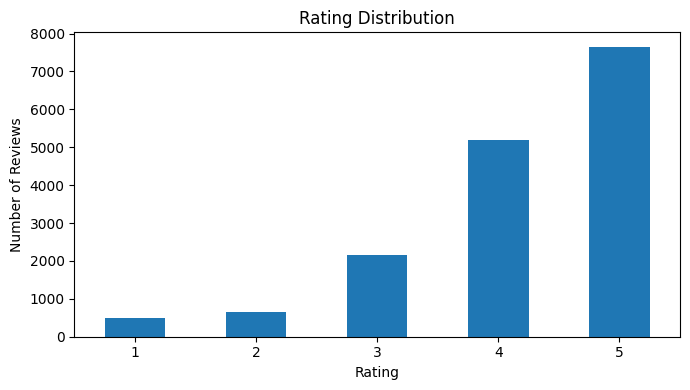

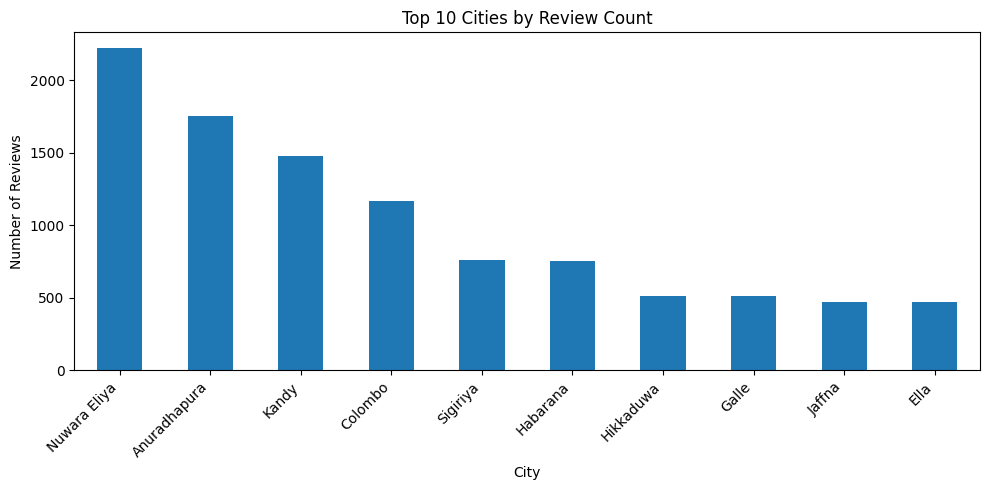

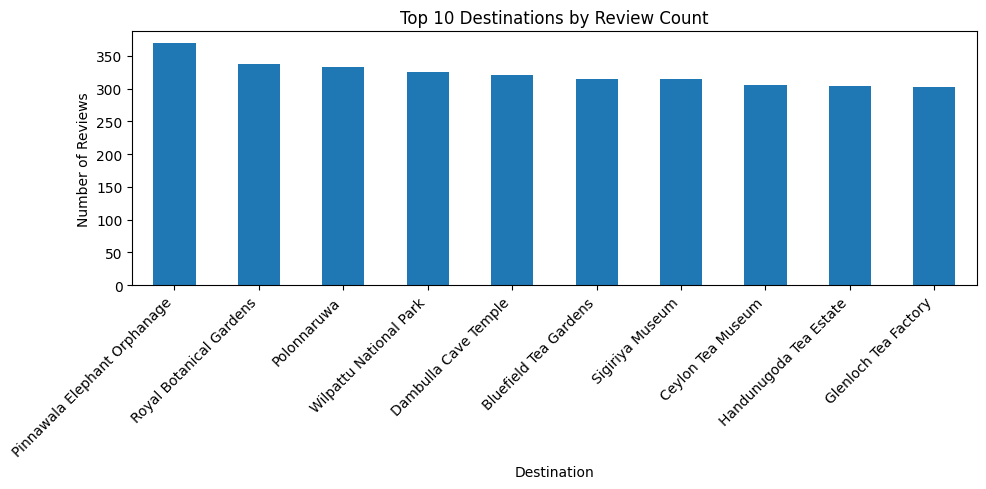

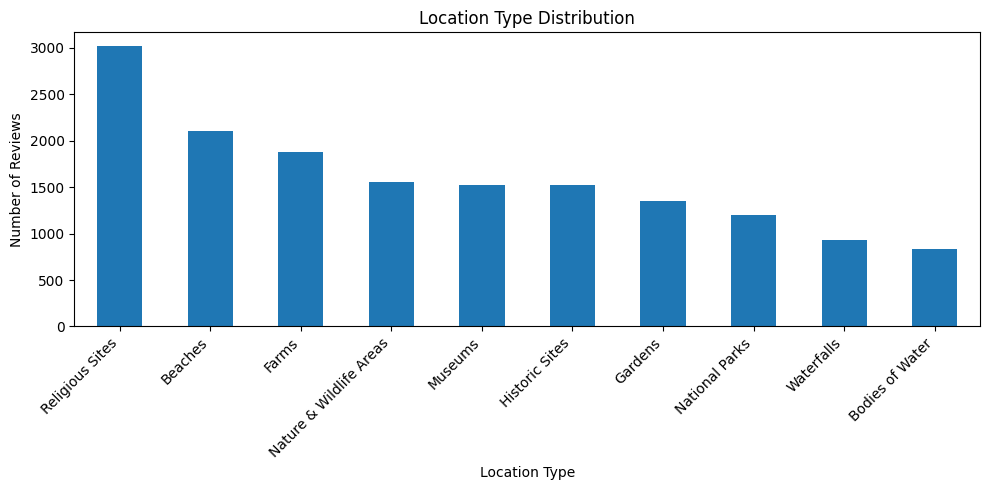

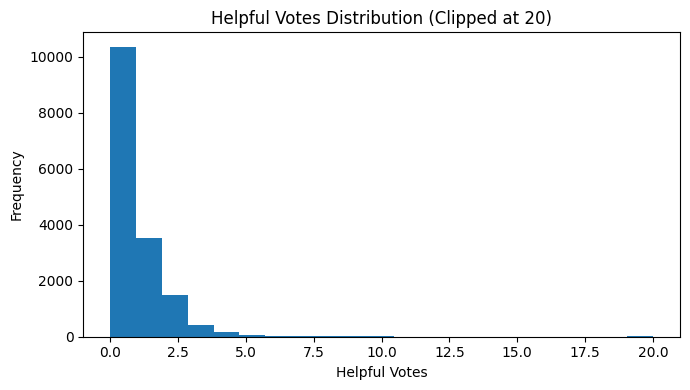

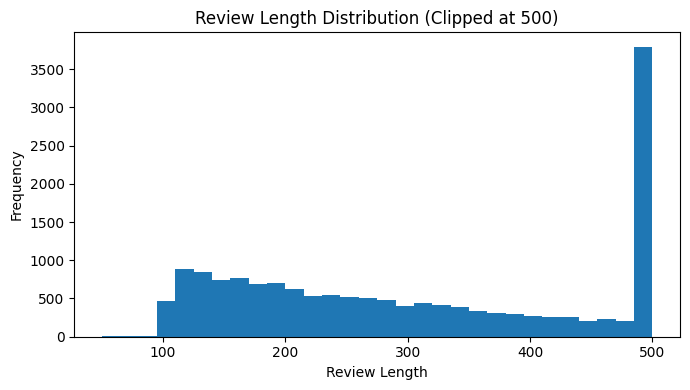

In [6]:
# --------------------------------------------
# 7. Plots
# --------------------------------------------
# Plot 1: Rating distribution
plt.figure(figsize=(7, 4))
df["Rating"].value_counts().sort_index().plot(kind="bar")
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Plot 2: Top 10 cities by review count
plt.figure(figsize=(10, 5))
df["Located_City"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Cities by Review Count")
plt.xlabel("City")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Plot 3: Top 10 destinations by review count
plt.figure(figsize=(10, 5))
df["Location_Name"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Destinations by Review Count")
plt.xlabel("Destination")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Plot 4: Location type distribution
plt.figure(figsize=(10, 5))
df["Location_Type"].value_counts().head(10).plot(kind="bar")
plt.title("Location Type Distribution")
plt.xlabel("Location Type")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Plot 5: Helpful votes distribution
if "Helpful_Votes" in df.columns:
    plt.figure(figsize=(7, 4))
    df["Helpful_Votes"].clip(upper=20).plot(kind="hist", bins=21)
    plt.title("Helpful Votes Distribution (Clipped at 20)")
    plt.xlabel("Helpful Votes")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

# Plot 6: Review length distribution
if "Review_Length" in df.columns:
    plt.figure(figsize=(7, 4))
    df["Review_Length"].clip(upper=500).plot(kind="hist", bins=30)
    plt.title("Review Length Distribution (Clipped at 500)")
    plt.xlabel("Review Length")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

In [7]:
# --------------------------------------------
# 8. Save key summary tables
# --------------------------------------------
avg_rating_by_type.to_csv("avg_rating_by_location_type.csv")
avg_rating_top_cities.to_csv("avg_rating_top_cities.csv")
df["Located_City"].value_counts().head(10).to_csv("top_10_cities_by_review_count.csv")
df["Location_Name"].value_counts().head(10).to_csv("top_10_destinations_by_review_count.csv")
print("\n✅ Descriptive analysis complete.")
print("Saved summary tables:")
print("- avg_rating_by_location_type.csv")
print("- avg_rating_top_cities.csv")
print("- top_10_cities_by_review_count.csv")
print("- top_10_destinations_by_review_count.csv")


✅ Descriptive analysis complete.
Saved summary tables:
- avg_rating_by_location_type.csv
- avg_rating_top_cities.csv
- top_10_cities_by_review_count.csv
- top_10_destinations_by_review_count.csv
